In [36]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import joblib
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
)

import matplotlib.pyplot as plt

print("Libraries imported successfully.")

Libraries imported successfully.


In [37]:
CURRENT_DIR = Path.cwd()

if CURRENT_DIR.name == "notebooks":
    PROJECT_ROOT = CURRENT_DIR.parent
else:
    PROJECT_ROOT = CURRENT_DIR

MODELS_DIR = PROJECT_ROOT / "models"

X = joblib.load(MODELS_DIR / "X_tfidf.pkl")
y = joblib.load(MODELS_DIR / "y.pkl")

print("Feature matrix shape:", X.shape)
print("Labels:", len(y))

Feature matrix shape: (5163, 5000)
Labels: 5163


In [38]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y,
)

print("Training Samples :", X_train.shape[0])
print("Testing Samples  :", X_test.shape[0])

Training Samples : 4130
Testing Samples  : 1033


In [39]:
models = {
    "Naive Bayes": MultinomialNB(),

    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=42,
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1,
    ),

    "Linear SVM": CalibratedClassifierCV(
    estimator=LinearSVC(random_state=42),
    cv=5
)}

print(models)

{'Naive Bayes': MultinomialNB(), 'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42), 'Random Forest': RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=42), 'Linear SVM': CalibratedClassifierCV(cv=5, estimator=LinearSVC(random_state=42))}


In [40]:
results = []

trained_models = {}

for name, model in models.items():

    print(f"\nTraining {name}...")

    model.fit(X_train, y_train)

    trained_models[name] = model

    predictions = model.predict(X_test)

    accuracy = accuracy_score(y_test, predictions)
    precision = precision_score(y_test, predictions)
    recall = recall_score(y_test, predictions)
    f1 = f1_score(y_test, predictions)

    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
    })

print("\nTraining completed.")


Training Naive Bayes...

Training Logistic Regression...

Training Random Forest...

Training Linear SVM...

Training completed.


In [41]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="F1 Score",
    ascending=False,
).reset_index(drop=True)

results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Linear SVM,0.986447,0.968000,0.923664,0.945312
1,Random Forest,0.977735,1.000000,0.824427,0.903766
2,Naive Bayes,0.974831,0.990654,0.809160,0.890756
3,Logistic Regression,0.950629,0.987805,0.618321,0.760563


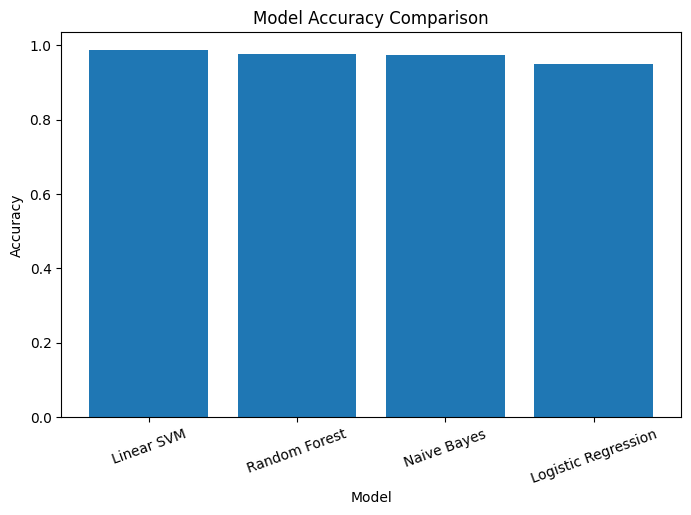

In [42]:
plt.figure(figsize=(8,5))

plt.bar(
    results_df["Model"],
    results_df["Accuracy"],
)

plt.title("Model Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy")

plt.xticks(rotation=20)

plt.show()

In [43]:
best_model_name = results_df.iloc[0]["Model"]

best_model = trained_models[best_model_name]

print("Best Model:", best_model_name)

Best Model: Linear SVM


In [44]:
best_predictions = best_model.predict(X_test)

print(classification_report(
    y_test,
    best_predictions,
))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99       902
           1       0.97      0.92      0.95       131

    accuracy                           0.99      1033
   macro avg       0.98      0.96      0.97      1033
weighted avg       0.99      0.99      0.99      1033



In [45]:
cm = confusion_matrix(
    y_test,
    best_predictions,
)

print(cm)

[[898   4]
 [ 10 121]]


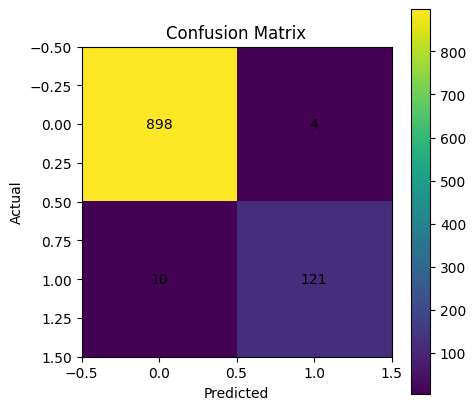

In [46]:
plt.figure(figsize=(5,5))

plt.imshow(cm)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center",
        )

plt.colorbar()

plt.show()

In [47]:
joblib.dump(
    best_model,
    MODELS_DIR / "classifier.pkl",
)

print("Best model saved.")

Best model saved.


In [48]:
results_df.to_csv(
    PROJECT_ROOT / "models" / "model_results.csv",
    index=False,
)

print("Results saved.")

Results saved.


In [49]:
loaded_model = joblib.load(
    MODELS_DIR / "classifier.pkl"
)

sample_sms = [
    "Congratulations! You have won a free iPhone. Click now to claim your prize."
]

vectorizer = joblib.load(
    MODELS_DIR / "tfidf.pkl"
)

sample_vector = vectorizer.transform(sample_sms)

prediction = loaded_model.predict(sample_vector)[0]

print("Prediction:", prediction)

if prediction == 1:
    print("Spam")
else:
    print("Ham")

Prediction: 1
Spam


In [50]:
print("=" * 70)
print("MODEL TRAINING SUMMARY")
print("=" * 70)

print(f"Training Samples : {X_train.shape[0]}")
print(f"Testing Samples  : {X_test.shape[0]}")

print()

print(results_df)

print()

print(f"Best Model : {best_model_name}")

print("=" * 70)

MODEL TRAINING SUMMARY
Training Samples : 4130
Testing Samples  : 1033

                 Model  Accuracy  Precision    Recall  F1 Score
0           Linear SVM  0.986447   0.968000  0.923664  0.945312
1        Random Forest  0.977735   1.000000  0.824427  0.903766
2          Naive Bayes  0.974831   0.990654  0.809160  0.890756
3  Logistic Regression  0.950629   0.987805  0.618321  0.760563

Best Model : Linear SVM
